# W&B Sweep — DQN
Búsqueda de hiperparámetros para el agente DQN en el ambiente Simple (CSTR).
- Método: Random Search
- Proyecto W&B: `Tesis_DQN`
- Arquitectura: Simple (CTRL únicamente)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

fatal: destination path 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning' already exists and is not an empty directory.


In [8]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Agente.DQN.train_DQN import DQNTrainer
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cu128
Device: CUDA


In [9]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Mar  7 15:07:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Login W&B

In [ ]:
!pip install wandb --quiet

In [3]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Configuración del Sweep

In [ ]:
WANDB_TEAM    = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN'

sweep_config = {
    'name':   'dqn_cstr_random_search',
    'method': 'random',

    'metric': {
        'name': 'eval_reward',
        'goal': 'maximize'
    },

    'parameters': {

        # ============ AMBIENTE ============
        'max_time_detector': {'values': [15, 30, 60]},
        'max_steps':         {'values': [20, 50, 100]},
        'reward_dead_band':  {'values': [0.01, 0.02, 0.05]},
        'delta_percent_ctrl':{'values': [0.05, 0.1, 0.2, 0.3]},

        # Reward weights — combinaciones predefinidas
        'reward_weights_idx': {
            'values': [0, 1, 2, 3]  # índice a la lista definida en sweep_run()
        },

        # ============ CRITERIOS DE ESTABILIDAD ============
        'error_increase_tolerance': {'values': [1.2, 1.5, 2.0]},
        'max_sign_changes_ratio':   {'values': [0.1, 0.2, 0.3]},
        'max_abrupt_change_ratio':  {'values': [0.03, 0.05, 0.1]},
        'abrupt_change_threshold':  {'values': [0.2, 0.3, 0.5]},

        # ============ AGENTE DQN ============
        'hidden_dims_idx':    {'values': [0, 1, 2, 3]},  # índice a lista en sweep_run()
        'lr':                 {'values': [0.00001, 0.0001, 0.001]},
        'epsilon_decay':      {'values': [0.999, 0.9995, 0.9999]},
        'target_update_freq': {'values': [50, 100, 200]},
        'batch_size':         {'values': [32, 64, 128]},
        'buffer_type':        {'values': ['simple', 'priority']},
        'buffer_size':        {'values': [5000, 10000, 50000]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_TEAM)
print(f'Sweep creado: {sweep_id}')

Create sweep with ID: 0evuvd3l
Sweep URL: https://wandb.ai/ve326684-universidad-ort-uruguay/Tesis_DQN/sweeps/0evuvd3l
Sweep creado: 0evuvd3l


## 4. Función de Entrenamiento

In [ ]:
# ============ LISTAS DE OPCIONES PREDEFINIDAS ============

REWARD_WEIGHTS_OPTIONS = [
    {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},   # 0: balanceado (default)
    {'error': 2.0, 'tiempo': 0.1, 'overshoot': 0.5, 'energy': 0.1},   # 1: foco en error y overshoot
    {'error': 1.0, 'tiempo': 0.5, 'overshoot': 0.1, 'energy': 0.5},   # 2: foco en tiempo y energía
    {'error': 3.0, 'tiempo': 0.1, 'overshoot': 0.1, 'energy': 0.05},  # 3: solo error importa
]

HIDDEN_DIMS_OPTIONS = [
    (64, 32),
    (128, 64),
    (128, 128, 64),
    (256, 128, 64),
]

# ============ FIJOS PARA TODOS LOS RUNS ============
SEED             = 42
N_EPISODES       = 300
EVAL_FREQUENCY   = 50
EARLY_STOPPING_PATIENCE   = 10
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
N_MANIPULABLE_VARS = 2
MANIPULABLE_RANGES = [(300, 420), (99.5, 102)]
VAR_NAMES          = ['T (K)', 'V (m³)']
DT                 = 1.0
DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'


def sweep_run():
    # -------- Inicializar run --------
    wandb.init()
    cfg = wandb.config

    # -------- Reproducibilidad --------
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    wandb.config.update({'seed': SEED}, allow_val_change=True)

    # -------- Resolver índices --------
    reward_weights = REWARD_WEIGHTS_OPTIONS[cfg.reward_weights_idx]
    hidden_dims    = HIDDEN_DIMS_OPTIONS[cfg.hidden_dims_idx]

    # Loggear valores reales (no índices) para legibilidad en W&B
    wandb.config.update({
        'reward_weights': str(reward_weights),
        'hidden_dims':    str(hidden_dims),
    }, allow_val_change=True)

    # -------- Configurar CSTR --------
    cstr = CSTRSimulator(
        dt=DT,
        control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
    )

    # -------- Construir config del trainer --------
    trainer_config = {
        # === AMBIENTE ===
        'env_config': {
            'architecture':    'simple',
            'env_type':        'simulation',
            'n_manipulable_vars': N_MANIPULABLE_VARS,
            'manipulable_ranges': MANIPULABLE_RANGES,
            'manipulable_setpoints': None,  # random en cada episodio
            'dt_usuario':      DT,
            'max_steps':       cfg.max_steps,
            'max_time_detector': cfg.max_time_detector,
            'reward_dead_band':  cfg.reward_dead_band,
            'delta_percent_ctrl': cfg.delta_percent_ctrl,
            'reward_weights':  reward_weights,
            'pid_limits': [
                (0.01, 5.0),
                (0.001, 1.0),
                (0.0001,   1.0)
            ],
            'agent_controller_config': {'agent_type': 'discrete'},
            'env_type_config': {
                'dt': DT,
                'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
            },
            # Criterios de estabilidad
            'stability_config': {
                'error_increase_tolerance': cfg.error_increase_tolerance,
                'max_sign_changes_ratio':   cfg.max_sign_changes_ratio,
                'max_abrupt_change_ratio':  cfg.max_abrupt_change_ratio,
                'abrupt_change_threshold':  cfg.abrupt_change_threshold,
            },
        },

        # === AGENTE DQN ===
        'agent_ctrl_config': {
            'state_dim':          N_MANIPULABLE_VARS * 5,  # 5 features por variable
            'action_dim':         7,
            'n_vars':             N_MANIPULABLE_VARS,
            'hidden_dims':        hidden_dims,
            'lr':                 cfg.lr,
            'gamma':              0.99,
            'epsilon_start':      1.0,
            'epsilon_min':        0.01,
            'epsilon_decay':      cfg.epsilon_decay,
            'batch_size':         cfg.batch_size,
            'target_update_freq': cfg.target_update_freq,
            'buffer_type':        cfg.buffer_type,
            'buffer_size':        cfg.buffer_size,
            'device':             DEVICE,
            'seed':               SEED,
        },

        # === ENTRENAMIENTO ===
        'n_episodes':          N_EPISODES,
        'eval_frequency':      EVAL_FREQUENCY,
        'save_frequency':      9999,  # no guardar checkpoints en sweep
        'log_frequency':       50,
        'checkpoint_dir':      f'checkpoints/dqn_{wandb.run.name}',
        'early_stopping_patience':      EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
        'use_wandb': True,
    }

    # -------- Conectar CSTR al ambiente --------
    # Se hace después de crear el trainer para acceder al proceso
    trainer = DQNTrainer(trainer_config)
    trainer.env.proceso.connect_external_process(cstr)

    # -------- Entrenar --------
    trainer.train()

    # -------- Métricas finales del run --------
    wandb.log({
        'final_eval_reward':  trainer.best_reward,
        'total_episodes':     len(trainer.episode_rewards),
        'final_epsilon':      trainer.epsilons[-1] if trainer.epsilons else 0,
        'final_reward_mean10': np.mean(trainer.episode_rewards[-10:]),
        'final_energy_mean10': np.mean(trainer.episode_energies[-10:]),
        'final_overshoot_mean10': np.mean(trainer.episode_max_overshoots[-10:]),
    })

    print(f'Run completado: {wandb.run.name}')
    wandb.finish()


## 5. Lanzar Sweep

In [ ]:
wandb.agent(sweep_id, function=sweep_run, count=30)

wandb: Agent Starting Run: 7k2tfgub with config:
wandb: 	abrupt_change_threshold: 0.2
wandb: 	batch_size: 128
wandb: 	buffer_size: 50000
wandb: 	buffer_type: simple
wandb: 	delta_percent_ctrl: 0.05
wandb: 	epsilon_decay: 0.9995
wandb: 	error_increase_tolerance: 2
wandb: 	hidden_dims_idx: 2
wandb: 	lr: 0.001
wandb: 	max_abrupt_change_ratio: 0.05
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 100
wandb: 	max_time_detector: 30
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 0
wandb: 	target_update_freq: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -0.46
  Length: 100
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 50/300
  Reward: -1.00
  Length: 100
  CTRL Loss: 9270.6234
  CTRL Epsilon: 0.0831
Evaluación: Reward promedio = -0.83
Agente guardado en: checkpoints/dqn_rare-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.63
  Length: 100
  CTRL Loss: 70677.6965
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -1.07
  Sin mejora: 1/10

Episodio 150/300
  Reward: -1.58
  Length: 100
  CTRL Loss: 314901.3143
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -0.56
Agente guardado en: checkpoints/dqn_rare-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/300
  Reward: -0.85
  Length: 100
  CTRL Loss: 731494.5814
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -0.94
  Sin mejora: 1/10

Episodio 250/300
  Reward: -0.68
  Length: 100
  CTRL Loss: 1913217.9477
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -1.12
  Sin mejora: 2/10
Run compl

energy,▂███▁▁█████████▇██▃▃████████▇▁█▁▂██▇█▁█▇
epsilon,█▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▅▂█▃▁
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▁▁▁▁▁▃▁▁▁▂▂▄▅▃▃▂▂▂▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▆▅▁█▁▁
kd_var1,▁▁▁▂▂▄▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▇▇▁▅▄▇█▁▁▁▁▁▁▂▂███
+8,...


wandb: Agent Starting Run: 5uth2x29 with config:
wandb: 	abrupt_change_threshold: 0.5
wandb: 	batch_size: 32
wandb: 	buffer_size: 50000
wandb: 	buffer_type: simple
wandb: 	delta_percent_ctrl: 0.2
wandb: 	epsilon_decay: 0.9999
wandb: 	error_increase_tolerance: 2
wandb: 	hidden_dims_idx: 2
wandb: 	lr: 0.0001
wandb: 	max_abrupt_change_ratio: 0.03
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 100
wandb: 	max_time_detector: 60
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 1
wandb: 	target_update_freq: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -0.40
  Length: 100
  CTRL Loss: 315139.1214
  CTRL Epsilon: 0.9931

Episodio 50/300
  Reward: -0.33
  Length: 100
  CTRL Loss: 5028.2094
  CTRL Epsilon: 0.6023
Evaluación: Reward promedio = -0.72
Agente guardado en: checkpoints/dqn_sweet-sweep-2/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.71
  Length: 100
  CTRL Loss: 37263.2868
  CTRL Epsilon: 0.3653
Evaluación: Reward promedio = -0.46
Agente guardado en: checkpoints/dqn_sweet-sweep-2/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -0.78
  Length: 100
  CTRL Loss: 245437.6727
  CTRL Epsilon: 0.2216
Evaluación: Reward promedio = -2.01
  Sin mejora: 1/10

Episodio 200/300
  Reward: -1.11
  Length: 100
  CTRL Loss: 1210709.6942
  CTRL Epsilon: 0.1344
Evaluación: Reward promedio = -1.12
  Sin mejora: 2/10

Episodio 250/300
  Reward: -2.14
  Length: 100
  CTRL Loss: 2200814.8144
  CTRL Epsilon: 0.0815
Evaluación: Reward promedio = -2.11
  Sin mejora: 3/10
R

...


Episodio 0/300
  Reward: -2.29
  Length: 50
  CTRL Loss: 243583.0683
  CTRL Epsilon: 0.9981

Episodio 50/300
  Reward: -0.06
  Length: 50
  CTRL Loss: 6473.9994
  CTRL Epsilon: 0.7773
Evaluación: Reward promedio = -0.81
Agente guardado en: checkpoints/dqn_azure-sweep-7/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.44
  Length: 50
  CTRL Loss: 102080.5796
  CTRL Epsilon: 0.6054
Evaluación: Reward promedio = -0.39
Agente guardado en: checkpoints/dqn_azure-sweep-7/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -0.76
  Length: 50
  CTRL Loss: 687058.6516
  CTRL Epsilon: 0.4715
Evaluación: Reward promedio = -1.13
  Sin mejora: 1/10

Episodio 200/300
  Reward: -1.73
  Length: 50
  CTRL Loss: 2227524.5703
  CTRL Epsilon: 0.3672
Evaluación: Reward promedio = -1.25
  Sin mejora: 2/10

Episodio 250/300
  Reward: -0.08
  Length: 50
  CTRL Loss: 4524048.2700
  CTRL Epsilon: 0.2859
Evaluación: Reward promedio = -1.09
  Sin mejora: 3/10
Run co

energy,▇▇▇▁▇▇▇▇▇██▇▇▇▇▇▇█▇▇▇█▇▇▇▇█▇█▇▇▇▇▇▇▇▇▇▇▇
epsilon,█████▇▇▇▇▆▆▆▆▆▆▅▅▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
eval_reward,▅█▂▁▂
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kd_var1,▁▁▁▁▁▁▁▁▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▅▁▁▁▁▁▁
+8,...


wandb: Agent Starting Run: 3ykum95z with config:
wandb: 	abrupt_change_threshold: 0.2
wandb: 	batch_size: 64
wandb: 	buffer_size: 50000
wandb: 	buffer_type: simple
wandb: 	delta_percent_ctrl: 0.2
wandb: 	epsilon_decay: 0.999
wandb: 	error_increase_tolerance: 1.2
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 0.0001
wandb: 	max_abrupt_change_ratio: 0.1
wandb: 	max_sign_changes_ratio: 0.3
wandb: 	max_steps: 50
wandb: 	max_time_detector: 60
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 3
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -0.20
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 50/300
  Reward: -3.54
  Length: 50
  CTRL Loss: 137413.8955
  CTRL Epsilon: 0.0831
Evaluación: Reward promedio = -2.51
Agente guardado en: checkpoints/dqn_morning-sweep-8/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -4.71
  Length: 50
  CTRL Loss: 449347.0078
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -3.97
  Sin mejora: 1/10


: 

In [ ]:
from Aux.Plots import SimplePlotter, print_summary

# Recuperar el mejor run del sweep
api = wandb.Api()
sweep = api.sweep(f'{WANDB_TEAM}/{WANDB_PROJECT}/{sweep_id}')
best_run = sorted(sweep.runs, key=lambda r: r.summary.get('eval_reward', -float('inf')), reverse=True)[0]

print(f'Mejor run: {best_run.name}')
print(f'eval_reward: {best_run.summary.get("eval_reward"):.4f}')
print(f'Hiperparámetros:')
for k, v in best_run.config.items():
    print(f'  {k}: {v}')

IndexError: list index out of range

## 6. Visualización local del mejor run


TEST 3
El mejor de W&B por 5.000 episodios

In [ ]:
# ============ FIJOS ============
SEED               = 42
N_EPISODES         = 5000
EVAL_FREQUENCY     = 50
EARLY_STOPPING_PATIENCE      = 20  # más paciente para run largo
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
N_MANIPULABLE_VARS = 2
MANIPULABLE_RANGES = [(300, 420), (99.5, 104)]
VAR_NAMES          = ['T (K)', 'V (m³)']
DT                 = 1.0
DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'

HIDDEN_DIMS_OPTIONS = [
    (64, 32),
    (128, 64),
    (128, 128, 64),
    (256, 128, 64),   # ← índice 3
]
REWARD_WEIGHTS_OPTIONS = [
    {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
    {'error': 2.0, 'tiempo': 0.1, 'overshoot': 0.5, 'energy': 0.1},
    {'error': 1.0, 'tiempo': 0.5, 'overshoot': 0.1, 'energy': 0.5},
    {'error': 3.0, 'tiempo': 0.1, 'overshoot': 0.1, 'energy': 0.05},  # ← índice 3
]

trainer_config = {
    'env_config': {
        'architecture':       'simple',
        'env_type':           'simulation',
        'n_manipulable_vars': N_MANIPULABLE_VARS,
        'manipulable_ranges': MANIPULABLE_RANGES,
        'manipulable_setpoints': None,
        'dt_usuario':         DT,
        'max_steps':          20,
        'max_time_detector':  60,
        'reward_dead_band':   0.02,
        'delta_percent_ctrl': 0.1,
        'reward_weights':     REWARD_WEIGHTS_OPTIONS[3],
        'pid_limits': [
            (0.01, 50.0),
            (0.001, 1.0),
            (0.0,   1.0)
        ],
        'agent_controller_config': {'agent_type': 'discrete'},
        'env_type_config': {
            'dt': DT,
            'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
        },
        'stability_config': {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio':   0.3,
            'max_abrupt_change_ratio':  0.03,
            'abrupt_change_threshold':  0.3,
        },
    },
    'agent_ctrl_config': {
        'state_dim':          N_MANIPULABLE_VARS * 5,
        'action_dim':         7,
        'n_vars':             N_MANIPULABLE_VARS,
        'hidden_dims':        HIDDEN_DIMS_OPTIONS[3],
        'lr':                 0.00001,
        'gamma':              0.99,
        'epsilon_start':      1.0,
        'epsilon_min':        0.01,
        'epsilon_decay':      0.999,
        'batch_size':         32,
        'target_update_freq': 200,
        'buffer_type':        'priority',
        'buffer_size':        10000,
        'device':             DEVICE,
        'seed':               SEED,
    },
    'n_episodes':          N_EPISODES,
    'eval_frequency':      EVAL_FREQUENCY,
    'save_frequency':      500,
    'log_frequency':       50,
    'checkpoint_dir':      'checkpoints/dqn_best_run',
    'early_stopping_patience':      EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
    'use_wandb': True,
}

# Inicializar W&B manualmente (sin sweep)
wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_TEAM,
    name='dqn_best_config_5000ep',
    config=trainer_config
)

cstr = CSTRSimulator(
    dt=DT,
    control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
)

trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

run_name = wandb.run.name
wandb.finish()
print(f'Run completado: {run_name}')


Episodio 0/5000
  Reward: -0.36
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 50/5000
  Reward: -0.94
  Length: 20
  CTRL Loss: 5313.7871
  CTRL Epsilon: 0.3718
Evaluación: Reward promedio = -0.89
Agente guardado en: checkpoints/dqn_best_run/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/5000
  Reward: -0.19
  Length: 20
  CTRL Loss: 1770.0711
  CTRL Epsilon: 0.1367
Evaluación: Reward promedio = -0.29
Agente guardado en: checkpoints/dqn_best_run/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/5000
  Reward: -3.31
  Length: 20
  CTRL Loss: 2782.0378
  CTRL Epsilon: 0.0503
Evaluación: Reward promedio = -3.85
  Sin mejora: 1/20

Episodio 200/5000
  Reward: -0.83
  Length: 20
  CTRL Loss: 4252.2352
  CTRL Epsilon: 0.0185
Evaluación: Reward promedio = -1.93
  Sin mejora: 2/20

Episodio 250/5000
  Reward: -0.98
  Length: 20
  CTRL Loss: 7899.4545
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -2.16
  Sin mejora: 3/20

Episodio 300/5000
  Rewa

KeyboardInterrupt: 

In [ ]:
import wandb
from google.colab import files

# ============ SUBIR CHECKPOINT ============
print("Subí el archivo agent_ctrl_ep500.pt")
uploaded = files.upload()

# ============ INICIALIZAR W&B ============
wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_TEAM,
    name='dqn_best_config_5000ep_resumed',
    config=trainer_config
)

# ============ CREAR TRAINER ============
cstr = CSTRSimulator(
    dt=DT,
    control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])
)

# Checkpoint dir a Drive para no perder nada
trainer_config['checkpoint_dir'] = '/content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run'
trainer_config['n_episodes'] = 4500  # restantes

trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)

# ============ CARGAR PESOS ============
trainer.agent_ctrl.load('agent_ctrl_ep500.pt')
trainer.agent_ctrl.epsilon = 0.5
print(f'Checkpoint cargado, epsilon: {trainer.agent_ctrl.epsilon}')

# ============ ENTRENAR ============
trainer.train()

# ============ GUARDAR PESOS EN W&B ============
import glob
for f in glob.glob('/content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/*.pt'):
    wandb.save(f)
    print(f'Guardado en W&B: {f}')

run_name = wandb.run.name
wandb.finish()
print(f'Run completado: {run_name}')

Subí el archivo agent_ctrl_ep500.pt


Saving agent_ctrl_ep500.pt to agent_ctrl_ep500.pt


energy,█▅▃▃▆▅▂▆▁▂▄▄▃▁▃▄▅▆▆▅▆▆▃▆▆▆▆▆▆▆▆▆▆▆▁▅▅▆▆▆
epsilon,█▇▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▇█▁▅▄▅▆▇▇▆▆▇
kd_var0,▁▅█▆▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kd_var1,▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▃▂▄██▇▅▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ki_var0,▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▃▃▃▂█▆▃▂▂▂▆▅▂▂▁▁▁▁▁▂▂▁▂▂▂
ki_var1,▇▇▇▇▅▆▇█▇▅▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kp_var0,▁▁▁▁▁▁▁▁▁▄▁█▃▁▁▃▄▁▁▁▂▁▂▁▁▃▃▄▄▁▁▆▂▂▃▁▁▆▁▁
kp_var1,▁▁▁▁▁▁▁▁▁▁█▇▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss,▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▅█
+2,...


Checkpoint cargado, epsilon: 0.5

Episodio 0/4500
  Reward: -0.32
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.5000

Episodio 50/4500
  Reward: -1.96
  Length: 20
  CTRL Loss: 61386.4886
  CTRL Epsilon: 0.1859
Evaluación: Reward promedio = -2.89
Agente guardado en: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/4500
  Reward: -3.70
  Length: 20
  CTRL Loss: 70138.7440
  CTRL Epsilon: 0.0683
Evaluación: Reward promedio = -2.89
  Sin mejora: 1/20
Agente guardado en: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/4500
  Reward: -1.12
  Length: 20
  CTRL Loss: 93713.2852
  CTRL Epsilon: 0.0251
Evaluación: Reward promedio = -2.10
Agente guardado en: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/4500
  Reward: -1.00
  Length: 20
  CTRL Loss: 159951.9051
  CTRL Epsilon: 0.0100
Ev

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Evaluación: Reward promedio = -1.66
  Sin mejora: 20/20
Early stopping en episodio 1750
Guardado en W&B: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_ep500.pt
Guardado en W&B: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_best.pt
Guardado en W&B: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_ep1500.pt
Guardado en W&B: /content/drive/MyDrive/PID_Agent/checkpoints/dqn_best_run/agent_ctrl_ep1000.pt


energy,▁██████████████████████████████████████▁
epsilon,█▅▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▂▂▅▁▅▆▅▆▅▆▆▆▅▇█▆█▄▆▆▇▆▅▇▅▅▆▅▅▇▆▅▅▅▆
kd_var0,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kd_var1,█▄▁▁▃▃████▇▆▆▆▇▇▇▇▇▆▅▅▅▅▅▆▆▄▄▆▅▅▅▆▅▇▇▇▇▆
ki_var0,▇█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
ki_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁████
kp_var0,▇█████████▇████▇█▆▆▇███▅▃▂▁▁▁▂▂▂▃▃▃▃▃▂▁▁
kp_var1,▁▁▁▁▁█▃▄█████████████████████████▇██████
loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▃▄▅█
+2,...


Run completado: dqn_best_config_5000ep_resumed


TEST 4
Continuo con la busqueda ya que no obtuve buenos resultados con el best anterior

In [ ]:
wandb.agent(sweep_id, function=sweep_run, count=10)

wandb: Agent Starting Run: axvn6o2v with config:
wandb: 	abrupt_change_threshold: 0.3
wandb: 	batch_size: 64
wandb: 	buffer_size: 5000
wandb: 	buffer_type: priority
wandb: 	delta_percent_ctrl: 0.2
wandb: 	epsilon_decay: 0.9995
wandb: 	error_increase_tolerance: 1.2
wandb: 	hidden_dims_idx: 2
wandb: 	lr: 1e-05
wandb: 	max_abrupt_change_ratio: 0.03
wandb: 	max_sign_changes_ratio: 0.1
wandb: 	max_steps: 50
wandb: 	max_time_detector: 60
wandb: 	reward_dead_band: 0.01
wandb: 	reward_weights_idx: 0
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -0.29
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 50/300
  Reward: -0.20
  Length: 50
  CTRL Loss: 722967.4594
  CTRL Epsilon: 0.2883
Evaluación: Reward promedio = -0.21
Agente guardado en: checkpoints/dqn_breezy-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.65
  Length: 50
  CTRL Loss: 122913.9721
  CTRL Epsilon: 0.0826
Evaluación: Reward promedio = -0.73
  Sin mejora: 1/10

Episodio 150/300
  Reward: -1.31
  Length: 50
  CTRL Loss: 563586.0591
  CTRL Epsilon: 0.0236
Evaluación: Reward promedio = -1.03
  Sin mejora: 2/10

Episodio 200/300
  Reward: -0.66
  Length: 50
  CTRL Loss: 10908780.2825
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -0.95
  Sin mejora: 3/10

Episodio 250/300
  Reward: -1.11
  Length: 50
  CTRL Loss: 28549507.9700
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -0.80
  Sin mejora: 4/10


wandb: Ctrl + C detected. Stopping sweep.


In [ ]:
wandb.agent(sweep_id, function=sweep_run, count=10)

wandb: Agent Starting Run: q7maye88 with config:
wandb: 	abrupt_change_threshold: 0.3
wandb: 	batch_size: 32
wandb: 	buffer_size: 10000
wandb: 	buffer_type: simple
wandb: 	delta_percent_ctrl: 0.1
wandb: 	epsilon_decay: 0.9999
wandb: 	error_increase_tolerance: 2
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 0.001
wandb: 	max_abrupt_change_ratio: 0.03
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 50
wandb: 	max_time_detector: 60
wandb: 	reward_dead_band: 0.05
wandb: 	reward_weights_idx: 2
wandb: 	target_update_freq: 200
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -1.22
  Length: 50
  CTRL Loss: 29860.2338
  CTRL Epsilon: 0.9981

Episodio 50/300
  Reward: -0.27
  Length: 50
  CTRL Loss: 1.3401
  CTRL Epsilon: 0.7773
Evaluación: Reward promedio = -1.06
Agente guardado en: checkpoints/dqn_silver-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.25
  Length: 50
  CTRL Loss: 0.4191
  CTRL Epsilon: 0.6054
Evaluación: Reward promedio = -0.74
Agente guardado en: checkpoints/dqn_silver-sweep-1/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -0.04
  Length: 50
  CTRL Loss: 0.6042
  CTRL Epsilon: 0.4715
Evaluación: Reward promedio = -1.08
  Sin mejora: 1/10

Episodio 200/300
  Reward: -2.34
  Length: 50
  CTRL Loss: 1.2978
  CTRL Epsilon: 0.3672
Evaluación: Reward promedio = -2.56
  Sin mejora: 2/10

Episodio 250/300
  Reward: -3.73
  Length: 50
  CTRL Loss: 2.0191
  CTRL Epsilon: 0.2859
Evaluación: Reward promedio = -3.14
  Sin mejora: 3/10
Run completado: silver-sweep-1

energy,▇▇▇▃▇█▇▇▇▁▁▁█▁▁▇▇▇█▇▇▇▇▇▁▇▇▇▇▁▇▇▇▇▇▇▇▂▇▇
epsilon,████▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
eval_reward,▇█▇▃▁
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▇▁▁▁▁▁▁▅█▅▄▃▁█▆
kd_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁██▇▁▁▁▁▁▁▂▁▁█▄▁▁▁▁▁▁▂▂▁▁▇
+8,...


wandb: Agent Starting Run: 86f14rbr with config:
wandb: 	abrupt_change_threshold: 0.5
wandb: 	batch_size: 32
wandb: 	buffer_size: 50000
wandb: 	buffer_type: priority
wandb: 	delta_percent_ctrl: 0.1
wandb: 	epsilon_decay: 0.999
wandb: 	error_increase_tolerance: 1.5
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 1e-05
wandb: 	max_abrupt_change_ratio: 0.05
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 50
wandb: 	max_time_detector: 30
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 3
wandb: 	target_update_freq: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -0.26
  Length: 50
  CTRL Loss: 74416.4375
  CTRL Epsilon: 0.9812

Episodio 50/300
  Reward: -5.73
  Length: 50
  CTRL Loss: 140228.6594
  CTRL Epsilon: 0.0804
Evaluación: Reward promedio = -3.47
Agente guardado en: checkpoints/dqn_bright-sweep-2/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.83
  Length: 50
  CTRL Loss: 6765.5143
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -1.60
Agente guardado en: checkpoints/dqn_bright-sweep-2/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -4.68
  Length: 50
  CTRL Loss: 868.7034
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -2.67
  Sin mejora: 1/10

Episodio 200/300
  Reward: -0.84
  Length: 50
  CTRL Loss: 218.3778
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -2.93
  Sin mejora: 2/10

Episodio 250/300
  Reward: -0.08
  Length: 50
  CTRL Loss: 90.6167
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -3.33
  Sin mejora: 3/10
Run completado: b

...


Episodio 0/300
  Reward: -0.30
  Length: 100
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 50/300
  Reward: -0.99
  Length: 100
  CTRL Loss: 3.3686
  CTRL Epsilon: 0.6082
Evaluación: Reward promedio = -0.88
Agente guardado en: checkpoints/dqn_smart-sweep-9/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.52
  Length: 100
  CTRL Loss: 4.7044
  CTRL Epsilon: 0.3689
Evaluación: Reward promedio = -1.11
  Sin mejora: 1/10

Episodio 150/300
  Reward: -0.02
  Length: 100
  CTRL Loss: 2.0817
  CTRL Epsilon: 0.2237
Evaluación: Reward promedio = -1.27
  Sin mejora: 2/10

Episodio 200/300
  Reward: -0.93
  Length: 100
  CTRL Loss: 1.5770
  CTRL Epsilon: 0.1357
Evaluación: Reward promedio = -0.54
Agente guardado en: checkpoints/dqn_smart-sweep-9/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 250/300
  Reward: -2.14
  Length: 100
  CTRL Loss: 0.9833
  CTRL Epsilon: 0.0823
Evaluación: Reward promedio = -2.80
  Sin mejora: 1/10
Run completado: smart-sweep-9


energy,▃▁█▂▆▆▆▆▆▇▇▇▇▇▇▇▇▁▁▇▇▇▇▇▇▇▇▇▇▇▅▇▇▇▇▆▇▇▆█
epsilon,██▇▇▆▆▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
eval_reward,▇▆▆█▁
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▆▅▁▁▁▂█▆▁▇▂▂▄▃▁
kd_var1,▁▁▁▁▁▁▁▂▁▂▂▂▁▁▁▁▁▁▁▁█▄▆▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+8,...


wandb: Agent Starting Run: h0h4nsjp with config:
wandb: 	abrupt_change_threshold: 0.2
wandb: 	batch_size: 32
wandb: 	buffer_size: 5000
wandb: 	buffer_type: simple
wandb: 	delta_percent_ctrl: 0.1
wandb: 	epsilon_decay: 0.999
wandb: 	error_increase_tolerance: 1.5
wandb: 	hidden_dims_idx: 2
wandb: 	lr: 0.0001
wandb: 	max_abrupt_change_ratio: 0.05
wandb: 	max_sign_changes_ratio: 0.2
wandb: 	max_steps: 50
wandb: 	max_time_detector: 15
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 2
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.



Episodio 0/300
  Reward: -2.54
  Length: 50
  CTRL Loss: 92175.6776
  CTRL Epsilon: 0.9812

Episodio 50/300
  Reward: -0.14
  Length: 50
  CTRL Loss: 20.4534
  CTRL Epsilon: 0.0804
Evaluación: Reward promedio = -2.27
Agente guardado en: checkpoints/dqn_glorious-sweep-10/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.02
  Length: 50
  CTRL Loss: 13.2939
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -1.22
Agente guardado en: checkpoints/dqn_glorious-sweep-10/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -2.77
  Length: 50
  CTRL Loss: 12.3583
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -2.28
  Sin mejora: 1/10

Episodio 200/300
  Reward: -1.68
  Length: 50
  CTRL Loss: 6.3913
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -1.24
  Sin mejora: 2/10

Episodio 250/300
  Reward: -2.97
  Length: 50
  CTRL Loss: 7.7658
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -2.11
  Sin mejora: 3/10
Run completado: glori

energy,▇▇▇▇▇▇█▇▇▇█▇▇▇███▁▇▃████▇█▇▇▇▇▇█▇▇▇▇▇▇▇█
epsilon,█▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▁█▁█▂
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▁▁▁▁▁▁▁▁██▃▁▁▁▁▁▁▁▁▁▁▁▁▇▃▂▂▁▁▃▁▁▁▁▁▁▁▁▇▅
kd_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▆▂▁▁▁▁▁▁▁▂██▄▂▁▁▁▁▁▁▁▁▁▁▁
+8,...


Analisis de datos

In [ ]:
import wandb
import pandas as pd

api = wandb.Api()
runs = api.runs('ve326684-universidad-ort-uruguay/Tesis_DQN')
print(f'Total runs: {len(runs)}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Total runs: 48


In [ ]:
for r in runs:
    print(r.name, '|', r.state, '|', r.config)

divine-sweep-1 | failed | {'lr': 0.0001, 'seed': 42, 'max_steps': 100, 'batch_size': 32, 'buffer_size': 50000, 'buffer_type': 'priority', 'hidden_dims': '(256, 128, 64)', 'epsilon_decay': 0.99, 'reward_weights': "{'error': 1.0, 'tiempo': 0.5, 'overshoot': 0.1, 'energy': 0.5}", 'hidden_dims_idx': 3, 'reward_dead_band': 0.05, 'max_time_detector': 60, 'delta_percent_ctrl': 0.1, 'reward_weights_idx': 2, 'target_update_freq': 50, 'max_sign_changes_ratio': 0.2, 'abrupt_change_threshold': 0.2, 'max_abrupt_change_ratio': 0.05, 'error_increase_tolerance': 2}
drawn-sweep-2 | failed | {'lr': 0.001, 'seed': 42, 'max_steps': 50, 'batch_size': 32, 'buffer_size': 50000, 'buffer_type': 'simple', 'hidden_dims': '(64, 32)', 'epsilon_decay': 0.995, 'reward_weights': "{'error': 3.0, 'tiempo': 0.1, 'overshoot': 0.1, 'energy': 0.05}", 'hidden_dims_idx': 0, 'reward_dead_band': 0.05, 'max_time_detector': 15, 'delta_percent_ctrl': 0.2, 'reward_weights_idx': 3, 'target_update_freq': 100, 'max_sign_changes_ratio

In [ ]:
runs_sweep = [r for r in runs if r.state == 'finished' and 'best_config' not in r.name]
print(len(runs_sweep), 'runs finished')
for r in runs_sweep:
    print(r.name, '|', r.id)

34 runs finished
amber-sweep-2 | im5xp03s
exalted-sweep-1 | 563ca4uo
denim-sweep-2 | fw299qso
whole-sweep-3 | baeyl2g2
bright-sweep-1 | 197xk11a
ruby-sweep-2 | wucp9iqh
whole-sweep-3 | sldz1d2s
amber-sweep-4 | un1vz1kv
wild-sweep-5 | h3wqfxkt
driven-sweep-6 | gy9r6u9c
gentle-sweep-7 | nwr725au
major-sweep-8 | en7a58ib
icy-sweep-9 | u43tae2n
peachy-sweep-1 | 0obwmc7x
worldly-sweep-1 | ywg1r8up
young-sweep-1 | j1mcd6rf
vibrant-sweep-2 | 7rn8j0ol
rare-sweep-1 | 7k2tfgub
sweet-sweep-2 | 5uth2x29
amber-sweep-3 | 93afzq0l
true-sweep-4 | 69u4r0o2
curious-sweep-5 | 31p6sggq
autumn-sweep-6 | 68jrv12k
azure-sweep-7 | e8gdvwv2
silver-sweep-1 | q7maye88
bright-sweep-2 | 86f14rbr
desert-sweep-3 | 00ngc0p0
winter-sweep-4 | 56mseyjx
twilight-sweep-5 | ah5kv70b
volcanic-sweep-6 | 0qk7jqqj
lively-sweep-7 | yu7nwu5k
azure-sweep-8 | 56glnr6m
smart-sweep-9 | nhu8vorf
glorious-sweep-10 | h0h4nsjp


In [ ]:
rows = []
for r in runs_sweep:
    s = dict(r.summary)
    rows.append({
        'name'        : r.name,
        'id'          : r.id,
        'reward'      : s.get('reward'),
        'eval_reward' : s.get('eval_reward'),
        'loss'        : s.get('loss'),
        'overshoot'   : s.get('overshoot'),
    })

df_sum = pd.DataFrame(rows).sort_values('eval_reward', ascending=False)
print(df_sum.to_string())

                 name        id      reward  eval_reward          loss  overshoot
29   volcanic-sweep-6  0qk7jqqj   -1.601997    -0.163546  2.114359e+01   1.199629
13     peachy-sweep-1  0obwmc7x   -1.350732    -0.189761  3.226076e+02   1.907683
12        icy-sweep-9  u43tae2n   -0.535510    -0.215033  5.152468e+03   1.199629
15      young-sweep-1  j1mcd6rf   -0.575002    -0.223573  2.590214e+05   1.888454
26     desert-sweep-3  00ngc0p0   -0.681029    -0.317120  1.033852e+02   0.887960
31      azure-sweep-8  56glnr6m   -0.112932    -0.389663  2.415494e+00   1.701386
20       true-sweep-4  69u4r0o2   -0.317039    -0.454419  4.794814e+03   1.640480
4      bright-sweep-1  197xk11a   -1.757250    -0.548049  1.894926e+04   2.359073
6       whole-sweep-3  sldz1d2s   -2.467987    -0.691301  2.267211e+06   2.359073
30     lively-sweep-7  yu7nwu5k   -0.080596    -1.025005  1.465181e+01   1.701386
5        ruby-sweep-2  wucp9iqh   -1.995689    -1.041328  1.617684e+05  21.753409
16    vibrant-sw

In [ ]:
top_ids = {'volcanic-sweep-6': '0qk7jqqj', 'desert-sweep-3': '00ngc0p0'}
top_hist = {}
for name, rid in top_ids.items():
    r = api.run(f've326684-universidad-ort-uruguay/Tesis_DQN/{rid}')
    top_hist[name] = pd.DataFrame(list(r.scan_history()))
    print(name, '→', len(top_hist[name]), 'steps')

volcanic-sweep-6 → 300 steps
desert-sweep-3 → 300 steps


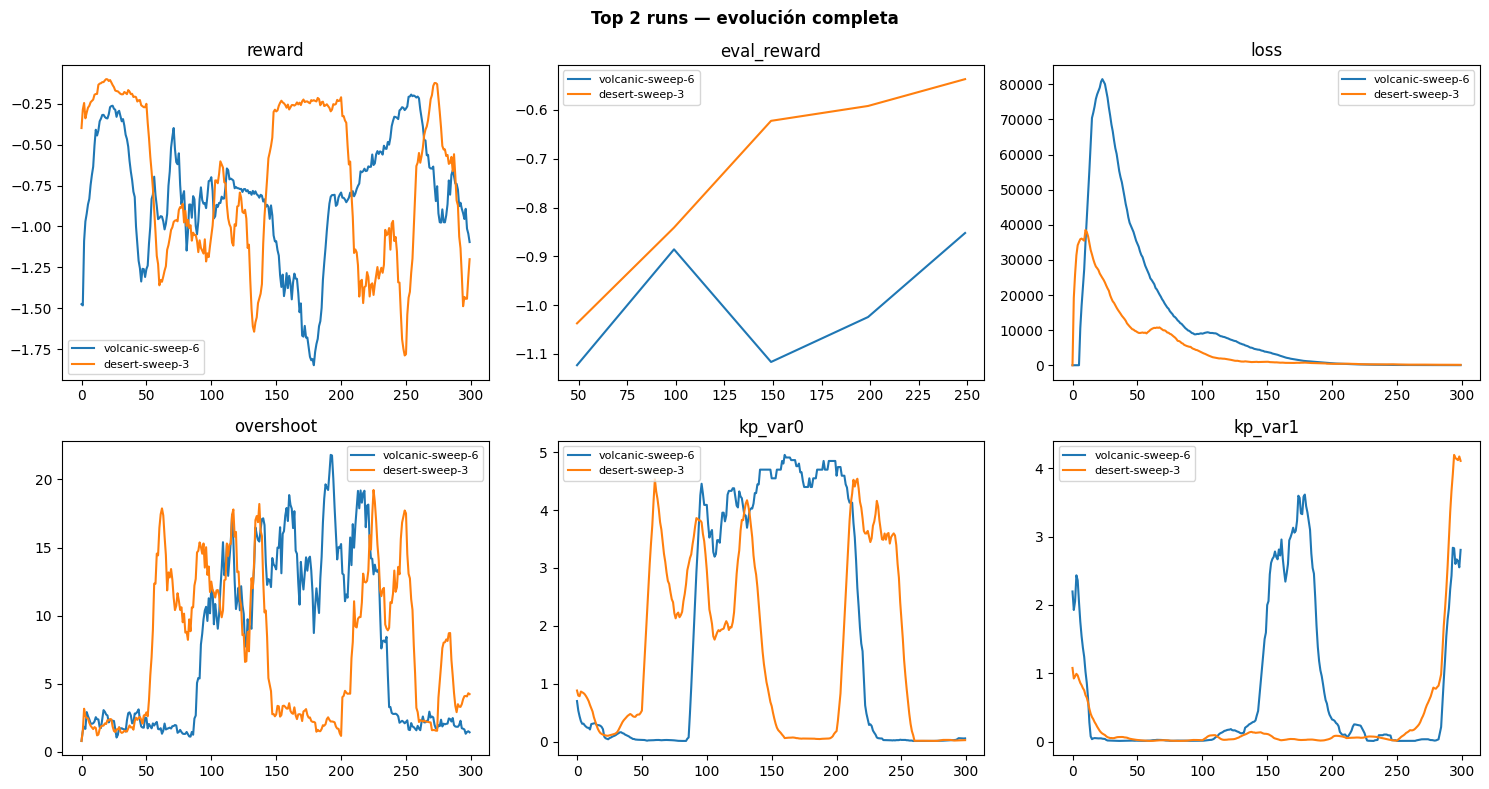

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metricas = ['reward', 'eval_reward', 'loss', 'overshoot', 'kp_var0', 'kp_var1']

for ax, col in zip(axes.flat, metricas):
    for name, df in top_hist.items():
        d = df[['_step', col]].dropna()
        ax.plot(d['_step'], d[col].rolling(10, min_periods=1).mean(), label=name)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Top 2 runs — evolución completa', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
r = api.run('ve326684-universidad-ort-uruguay/Tesis_DQN/0qk7jqqj')
print(r.config)

{'lr': 1e-05, 'seed': 42, 'max_steps': 20, 'batch_size': 128, 'buffer_size': 50000, 'buffer_type': 'priority', 'hidden_dims': '(64, 32)', 'epsilon_decay': 0.9995, 'reward_weights': "{'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1}", 'hidden_dims_idx': 0, 'reward_dead_band': 0.02, 'max_time_detector': 15, 'delta_percent_ctrl': 0.3, 'reward_weights_idx': 0, 'target_update_freq': 50, 'max_sign_changes_ratio': 0.2, 'abrupt_change_threshold': 0.3, 'max_abrupt_change_ratio': 0.03, 'error_increase_tolerance': 1.2}


TEST 5 - correr 15000 episodios

In [25]:
# ============ CONFIG RUN PRINCIPAL POST-FIX ============
import wandb
import torch
import random
import numpy as np

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN'
RUN_NAME      = 'dqn_postfix_15k'

N_EPISODES               = 15000
EVAL_FREQUENCY           = 100
LOG_FREQUENCY            = 100
SAVE_FREQUENCY           = 2000
EARLY_STOPPING_PATIENCE  = 50
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
SEED                     = 42

trainer_config = {
    'env_config': {
        'architecture'        : 'simple',
        'env_type'            : 'simulation',
        'n_manipulable_vars'  : 2,
        'manipulable_ranges'  : [(300, 420), (99.5, 102)],
        'manipulable_setpoints': None,
        'dt_usuario'          : 1.0,
        'max_steps'           : 20,
        'max_time_detector'   : 15,
        'reward_dead_band'    : 0.02,
        'delta_percent_ctrl'  : 0.3,
        'reward_weights'      : {'error': 3.0, 'tiempo': 0.1, 'overshoot': 0.1, 'energy': 0.05},
        'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
        'agent_controller_config': {'agent_type': 'discrete'},
        'env_type_config'     : {'dt': 1.0, 'control_limits': ((300, 420), (99.5, 102))},
        'stability_config'    : {
            'error_increase_tolerance': 1.2,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.03,
            'abrupt_change_threshold' : 0.3,
        },
    },
    'agent_ctrl_config': {
        'state_dim'         : 10,
        'action_dim'        : 7,
        'n_vars'            : 2,
        'hidden_dims'       : (128, 64),
        'lr'                : 1e-05,
        'gamma'             : 0.99,
        'epsilon_start'     : 1.0,
        'epsilon_min'       : 0.01,
        'epsilon_decay'     : 0.9995,
        'batch_size'        : 128,
        'target_update_freq': 50,
        'buffer_type'       : 'priority',
        'buffer_size'       : 50000,
        'device'            : 'cuda' if torch.cuda.is_available() else 'cpu',
        'seed'              : SEED,
    },
    'n_episodes'     : N_EPISODES,
    'eval_frequency' : EVAL_FREQUENCY,
    'log_frequency'  : LOG_FREQUENCY,
    'save_frequency' : SAVE_FREQUENCY,
    'checkpoint_dir' : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'     : EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
    'use_wandb': True,
}

# ============ REPRODUCIBILIDAD ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ============ INIT WANDB ============
wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['post-fix', 'clamp', '15k', 'produccion'],  # fácil de filtrar en W&B
    config  = trainer_config,
)

# ============ ENTRENAR ============
cstr    = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

# ============ GUARDAR PESOS EN W&B ============
import os
checkpoint_path = f'checkpoints/{RUN_NAME}'
if os.path.exists(checkpoint_path):
    artifact = wandb.Artifact(
        name = f'model_{RUN_NAME}',
        type = 'model',
        description = 'Pesos DQN post-fix clamp, 15k episodios'
    )
    artifact.add_dir(checkpoint_path)
    wandb.log_artifact(artifact)

# ============ MÉTRICAS FINALES ============
wandb.log({
    'final_eval_reward'      : trainer.best_reward,
    'total_episodes'         : len(trainer.episode_rewards),
    'final_epsilon'          : trainer.epsilons[-1] if trainer.epsilons else 0,
    'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
    'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
    'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
})

wandb.finish()
print(f'Run completado: {RUN_NAME}')


Episodio 0/15000
  Reward: -2.13
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 1.0000

Episodio 100/15000
  Reward: -0.26
  Length: 20
  CTRL Loss: 99.8624
  CTRL Epsilon: 0.3880
Evaluación: Reward promedio = -0.42
Agente guardado en: checkpoints/dqn_postfix_15k/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 200/15000
  Reward: -0.19
  Length: 20
  CTRL Loss: 26.5151
  CTRL Epsilon: 0.1427
Evaluación: Reward promedio = -0.46
  Sin mejora: 1/50

Episodio 300/15000
  Reward: -0.85
  Length: 20
  CTRL Loss: 16.0261
  CTRL Epsilon: 0.0525
Evaluación: Reward promedio = -1.32
  Sin mejora: 2/50

Episodio 400/15000
  Reward: -0.80
  Length: 20
  CTRL Loss: 10.7413
  CTRL Epsilon: 0.0193
Evaluación: Reward promedio = -1.10
  Sin mejora: 3/50

Episodio 500/15000
  Reward: -0.98
  Length: 20
  CTRL Loss: 6.1248
  CTRL Epsilon: 0.0100
Evaluación: Reward promedio = -1.38
  Sin mejora: 4/50

Episodio 600/15000
  Reward: -0.65
  Length: 20
  CTRL Loss: 4.2500
  CTRL Epsilon: 0.0100
Evalu

wandb: Adding directory to artifact (checkpoints/dqn_postfix_15k)... Done. 0.0s


Evaluación: Reward promedio = -1.22
  Sin mejora: 50/50
Early stopping en episodio 14000


energy,▇▅▇▇▁▇▆▆█▆▁▇▆▆█▇▁▇▇▇▇▇▁▆▇▁▁▁▁▁▁█▆▇▇▇▆▆█▇
epsilon,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▇▄▄▅▅▃▇▇▆▄▇▇▇▇▆▆▆▇▇▄▇▆▆▆▇▅▂▂▇▇█▇██▁▇▇██▄
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
kd_var0,▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
kd_var1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▄█▁▁█▂██████▄█▁▁▁▁█▇▁▁▅▁
+8,...


Run completado: dqn_postfix_15k


Analisis de resultados

In [10]:
api = wandb.Api()
r = api.run('ve326684-universidad-ort-uruguay/Tesis_DQN/71zrcye0')
df_post = pd.DataFrame(list(r.scan_history()))
print(len(df_post), 'steps logueados')
print(df_post.columns.tolist())

14001 steps logueados
['kd_var1', 'ki_var0', 'kp_var1', 'reward', 'kd_var0', 'ki_var1', 'loss', 'overshoot', '_runtime', 'epsilon', 'energy', '_timestamp', 'kp_var0', '_step', 'eval_reward', 'final_overshoot_mean10', 'total_episodes', 'final_energy_mean10', 'final_epsilon', 'final_reward_mean10', 'final_eval_reward']


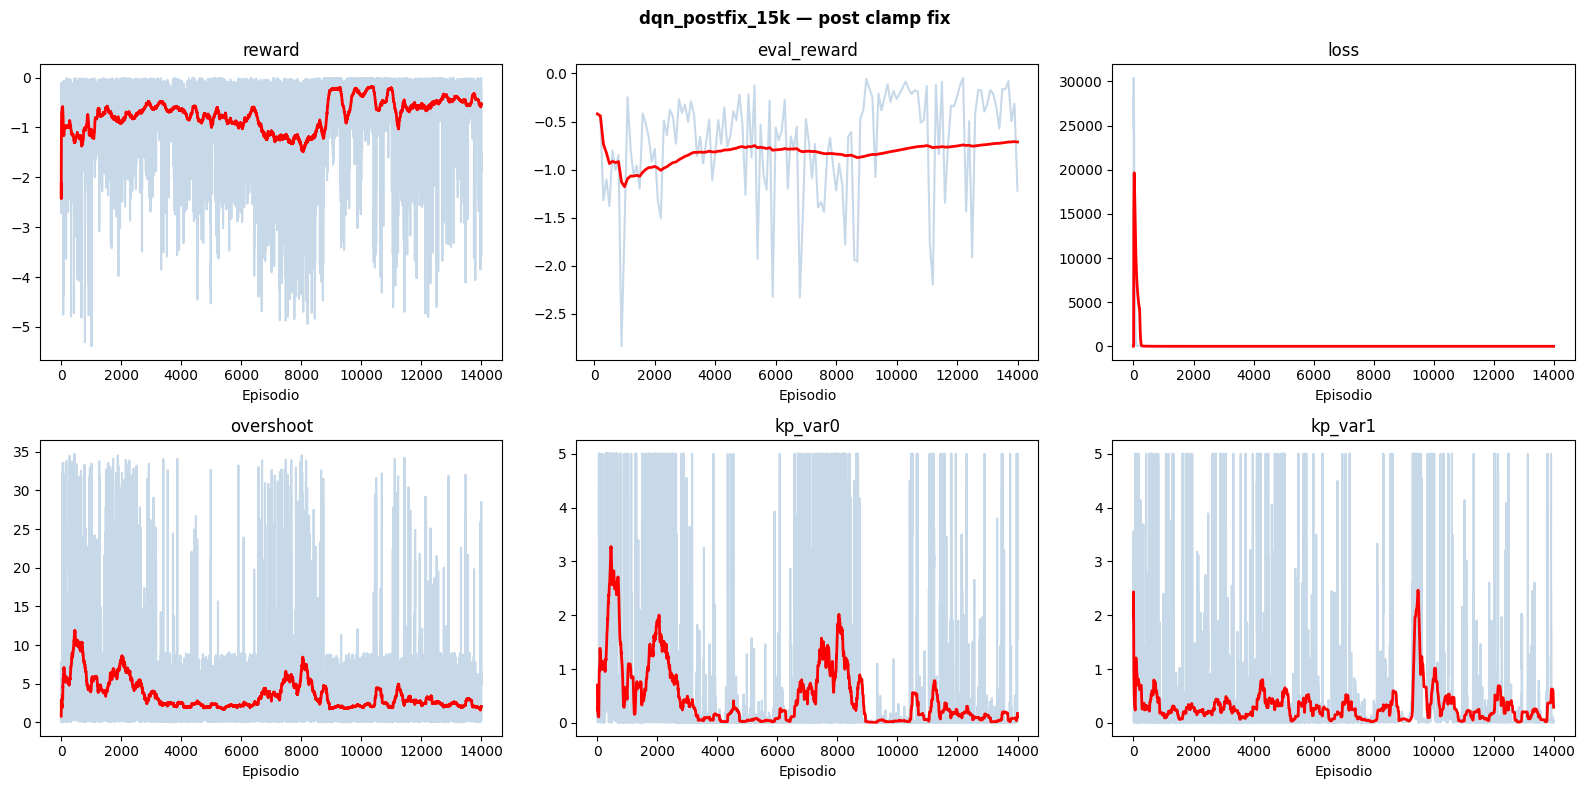

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metricas = ['reward', 'eval_reward', 'loss', 'overshoot', 'kp_var0', 'kp_var1']

for ax, col in zip(axes.flat, metricas):
    d = df_post[['_step', col]].dropna()
    ax.plot(d['_step'], d[col], alpha=0.3, color='steelblue')
    ax.plot(d['_step'], d[col].rolling(200, min_periods=1).mean(), color='red', lw=2)
    ax.set_title(col)
    ax.set_xlabel('Episodio')

plt.suptitle('dqn_postfix_15k — post clamp fix', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
from Agente.DQN.algorithm_DQN import DQNAgent
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction

In [11]:
agent = DQNAgent(
    state_dim=10,
    action_dim=7,
    n_vars=2,
    agent_role='ctrl',
    hidden_dims=(128, 64),
    device='cpu',
    seed=42
)
agent.load('/content/Checkpoints/agent_ctrl_best.pt')
agent.epsilon = 0.0  # sin exploración, pura explotación
print('Agente cargado')

Agente cargado


Prueba de funcionamiento del agente

In [19]:
cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 104)))
cstr.reset()

pid_controllers = [
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(300, 420)),
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(99.5, 104))
]
apply_action = ApplyAction(
    delta_percent_ctrl=0.3,
    pid_limits=[(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
    manipulable_ranges=[(300, 420), (99.5, 104)]
)

T_sp, V_sp = 340.0, 100.0
sps = [T_sp, V_sp]
pvs = [cstr.T_ss, cstr.V_ss]

# Acumular errores entre steps
error_integral = [0.0, 0.0]
error_prev     = [sps[i] - pvs[i] for i in range(2)]

traj_T, traj_V = [pvs[0]], [pvs[1]]
traj_kp0, traj_kp1 = [], []

for step in range(20):
    errors = [sps[i] - pvs[i] for i in range(2)]

    # Acumular integral y derivada
    for i in range(2):
        error_integral[i] += errors[i] * 1.0
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent.select_action(state, training=False)
    print(f'Step {step+1:2d} | action={action}', end='')

    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='discrete',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    traj_kp0.append(pid_controllers[0].kp)
    traj_kp1.append(pid_controllers[1].kp)

    detector = ResponseTimeDetector(proceso=cstr, env_type='simulation', dt=1.0, tolerance=0.02)
    resultado = detector.estimate(pvs_inicial=pvs, sps=sps, pid_controllers=pid_controllers, max_time=15)

    pvs = resultado['pvs_final']
    traj_T.append(pvs[0])
    traj_V.append(pvs[1])
    print(f' | T={pvs[0]:.2f} | V={pvs[1]:.3f} | kp0={pid_controllers[0].kp:.4f} | kp1={pid_controllers[1].kp:.4f}')

Step  1 | action=[5 4] | T=329.53 | V=100.540 | kp0=1.0000 | kp1=1.0000
Step  2 | action=[5 5] | T=330.26 | V=100.020 | kp0=1.0000 | kp1=1.0000
Step  3 | action=[5 5] | T=330.51 | V=99.825 | kp0=1.0000 | kp1=1.0000
Step  4 | action=[5 5] | T=330.35 | V=99.750 | kp0=1.0000 | kp1=1.0000
Step  5 | action=[5 5] | T=330.49 | V=99.730 | kp0=1.0000 | kp1=1.0000
Step  6 | action=[5 5] | T=330.61 | V=99.719 | kp0=1.0000 | kp1=1.0000
Step  7 | action=[5 5] | T=330.42 | V=99.701 | kp0=1.0000 | kp1=1.0000
Step  8 | action=[5 5] | T=330.40 | V=99.716 | kp0=1.0000 | kp1=1.0000
Step  9 | action=[5 5] | T=330.58 | V=99.732 | kp0=1.0000 | kp1=1.0000
Step 10 | action=[5 5] | T=330.43 | V=99.705 | kp0=1.0000 | kp1=1.0000
Step 11 | action=[5 5] | T=330.48 | V=99.706 | kp0=1.0000 | kp1=1.0000
Step 12 | action=[5 5] | T=330.41 | V=99.727 | kp0=1.0000 | kp1=1.0000
Step 13 | action=[1 5] | T=332.06 | V=99.728 | kp0=1.0000 | kp1=1.0000
Step 14 | action=[1 5] | T=334.17 | V=99.710 | kp0=1.0000 | kp1=1.0000
Step

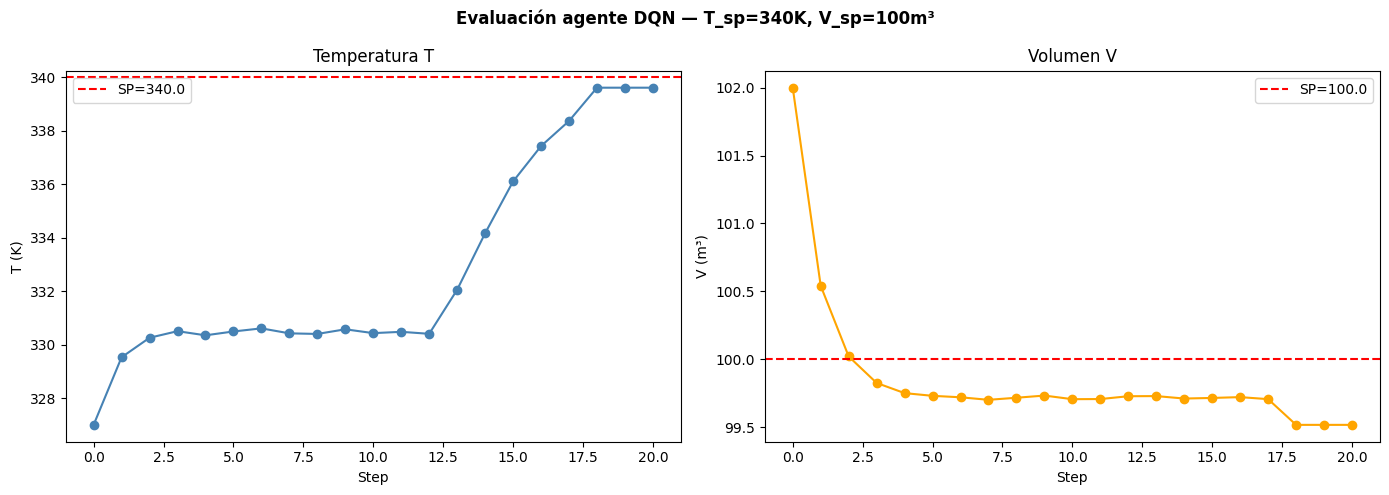

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_T, marker='o', color='steelblue')
axes[0].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp}')
axes[0].set_title('Temperatura T')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('T (K)')
axes[0].legend()

axes[1].plot(traj_V, marker='o', color='orange')
axes[1].axhline(V_sp, color='red', linestyle='--', label=f'SP={V_sp}')
axes[1].set_title('Volumen V')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('V (m³)')
axes[1].legend()

plt.suptitle('Evaluación agente DQN — T_sp=340K, V_sp=100m³', fontweight='bold')
plt.tight_layout()
plt.show()

Se detecta un bug, durante el entrnemaiento se restea el pid, lo cual tiene sentido, pero en explotacion no!! se corriije eso y se vuelve a probar

In [14]:
cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 104)))
cstr.reset()

pid_controllers = [
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(300, 420)),
    PIDController(kp=1.0, ki=0.1, kd=0.01, dt=1.0, output_limits=(99.5, 104))
]
apply_action = ApplyAction(
    delta_percent_ctrl=0.3,
    pid_limits=[(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
    manipulable_ranges=[(300, 420), (99.5, 104)]
)

T_sp, V_sp = 340.0, 100.0
sps = [T_sp, V_sp]
pvs = [cstr.T_ss, cstr.V_ss]

# Acumular errores entre steps
error_integral = [0.0, 0.0]
error_prev     = [sps[i] - pvs[i] for i in range(2)]

traj_T, traj_V = [pvs[0]], [pvs[1]]
traj_kp0, traj_kp1 = [], []

detector = ResponseTimeDetector(proceso=cstr, env_type='simulation', dt=1.0, tolerance=0.02)
for step in range(20):
    errors = [sps[i] - pvs[i] for i in range(2)]

    # Acumular integral y derivada
    for i in range(2):
        error_integral[i] += errors[i] * 1.0
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent.select_action(state, training=False)
    print(f'Step {step+1:2d} | action={action}', end='')

    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='discrete',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    traj_kp0.append(pid_controllers[0].kp)
    traj_kp1.append(pid_controllers[1].kp)


    resultado = detector.estimate(pvs_inicial=pvs, sps=sps, pid_controllers=pid_controllers, max_time=15, reset_pid=False)

    pvs = resultado['pvs_final']
    traj_T.append(pvs[0])
    traj_V.append(pvs[1])
    print(f' | T={pvs[0]:.2f} | V={pvs[1]:.3f} | kp0={pid_controllers[0].kp:.4f} | kp1={pid_controllers[1].kp:.4f}')

Step  1 | action=[5 4] | T=329.46 | V=100.546 | kp0=1.0000 | kp1=1.0000
Step  2 | action=[5 5] | T=334.58 | V=100.186 | kp0=1.0000 | kp1=1.0000
Step  3 | action=[3 5] | T=336.89 | V=100.074 | kp0=0.7000 | kp1=1.0000
Step  4 | action=[3 5] | T=338.52 | V=100.012 | kp0=0.4900 | kp1=1.0000
Step  5 | action=[3 5] | T=339.40 | V=100.014 | kp0=0.3430 | kp1=1.0000
Step  6 | action=[3 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step  7 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step  8 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step  9 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step 10 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step 11 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step 12 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step 13 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
Step 14 | action=[5 5] | T=339.60 | V=99.999 | kp0=0.2401 | kp1=1.0000
S

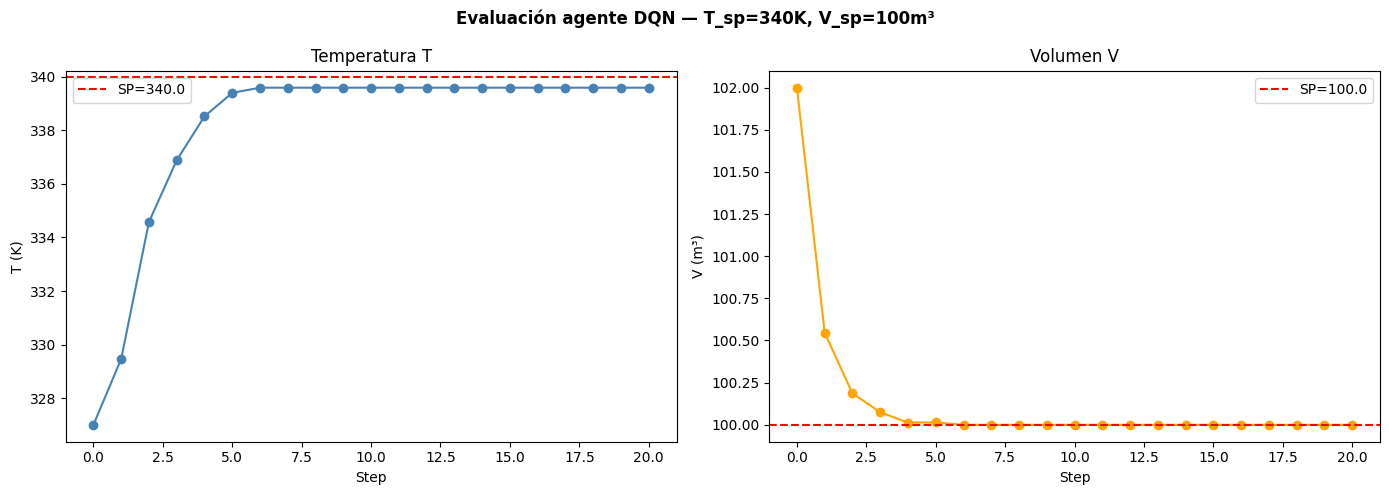

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_T, marker='o', color='steelblue')
axes[0].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp}')
axes[0].set_title('Temperatura T')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('T (K)')
axes[0].legend()

axes[1].plot(traj_V, marker='o', color='orange')
axes[1].axhline(V_sp, color='red', linestyle='--', label=f'SP={V_sp}')
axes[1].set_title('Volumen V')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('V (m³)')
axes[1].legend()

plt.suptitle('Evaluación agente DQN — T_sp=340K, V_sp=100m³', fontweight='bold')
plt.tight_layout()
plt.show()

El agente aprendio muy bien! llega rapido y sin overshots! Paso al entrenamiento del orch.